In [208]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os
from pathlib import Path

# Set working directory to project root
project_root = Path.cwd().parent if (Path.cwd() / "qualitative_results.ipynb").exists() else Path.cwd()
os.chdir(project_root)

LABELS = {'jpeg': 'JPEG', 'turbo_ddcm': 'Turbo-DDCM', 'robust_turbo_ddcm': 'Robust Turbo-DDCM', 'ddcm': 'DDCM', 'bpg': 'BPG', 'robustB10' : 'Robust Turbo-DDCM B=10', 'diffc' : 'DiffC', 'illm' : 'ILLM', 'VAE Bound' : 'VAE Bound', 'stable_codec' : 'StableCodec', 'original' : 'Original'}

def tex_label(text: str) -> str:
    """Wrap plain text into LaTeX mathrm with escaped spaces."""
    return r"$\mathrm{" + text.replace(" ", r"\ ") + "}$"

plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

In [209]:
def get_paths(method, dataset_name, img_index, ber_str, num):
    if method == 'original':
        return [f'{dataset_name}/{img_index}.png']

    base_path = f'results/noisy_channel/{method}/{dataset_name}/samples/ber{ber_str}'

    if not os.path.exists(base_path):
        raise FileNotFoundError(f"Folder does not exist: {base_path}")

    all_files = os.listdir(base_path)
    filtered = [f for f in all_files if f.startswith(str(img_index)) and f.endswith(".png")]
    filtered.sort()
    selected = filtered[:num]
    full_paths = [os.path.join(base_path, f) for f in selected]

    while len(full_paths) < num:
        full_paths += ['x'] # corrupted file

    return full_paths


In [210]:
def plot_4x(paths, methods, title=None, save_name=None, top_original=None):
    assert len(paths) == 2
    for g in paths:
        assert len(g) == 4

    fig, axes_ = plt.subplots(2, 4, figsize=(15, 9))

    # leave space for the original image
    if top_original is not None:
        plt.subplots_adjust(top=0.75)
    else:
        plt.subplots_adjust(top=0.95)

    # --- Top original image ---
    if top_original is not None:
        img = Image.open(top_original)
        img = np.array(img)

        ax_top = fig.add_axes([0.75/2, 0.8, 0.25, 0.25])  # centered at top
        ax_top.imshow(img)
        ax_top.axis("off")
        ax_top.set_title(tex_label("Original"), fontsize=18)

    for idx in range(2):
        axes = axes_[idx] if isinstance(axes_[idx], np.ndarray) else [axes_[idx]]

        for col_idx, group in enumerate(paths[idx]):

            ax = axes[col_idx]
            ax.axis("off")
            ax.set_title(tex_label(LABELS[methods[idx][col_idx]]), fontsize=18)

            if methods[idx][col_idx] == 'original':
                img = np.array(Image.open(group[0]))
                ax.imshow(img)
                continue

            width = 0.48
            height = 0.48

            positions = [
                [0, 1-height],
                [1-width, 1-height],
                [0, 0],
                [1-width, 0],
            ]

            for img_path, pos in zip(group, positions):
                x, y = pos
                inset_ax = ax.inset_axes([x, y, width, height])
                inset_ax.set_box_aspect(1)  # make inset square

                try:
                    img = np.array(Image.open(img_path))
                    inset_ax.imshow(img, aspect='auto')
                    inset_ax.axis("off")
                except Exception as e:
                    # if image cannot be loaded, show blank square with text
                    inset_ax.imshow(np.ones((10, 10, 3)))  # white square
                    inset_ax.text(0.5, 0.5, "Corrupted \n File",
                                  ha='center', va='center',
                                  fontsize=14, color='black',
                                  transform=inset_ax.transAxes)
                    # for spine in inset_ax.spines.values():
                    #     spine.set_edgecolor('black')
                    #     spine.set_linewidth(1)
                    #
                    #     inset_ax.set_xticks([])
                    #     inset_ax.set_yticks([])
                    inset_ax.axis("off")

                # img = np.array(Image.open(img_path))
                #
                # x, y = pos
                # inset_ax = ax.inset_axes([x, y, width, height])
                # ax.set_box_aspect(1)
                # inset_ax.imshow(img)
                # inset_ax.axis("off")

    if save_name is None:
        plt.show()
    else:
        output_dir = 'results/plots'
        output_path = os.path.join(output_dir, f'{save_name}.pdf')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')

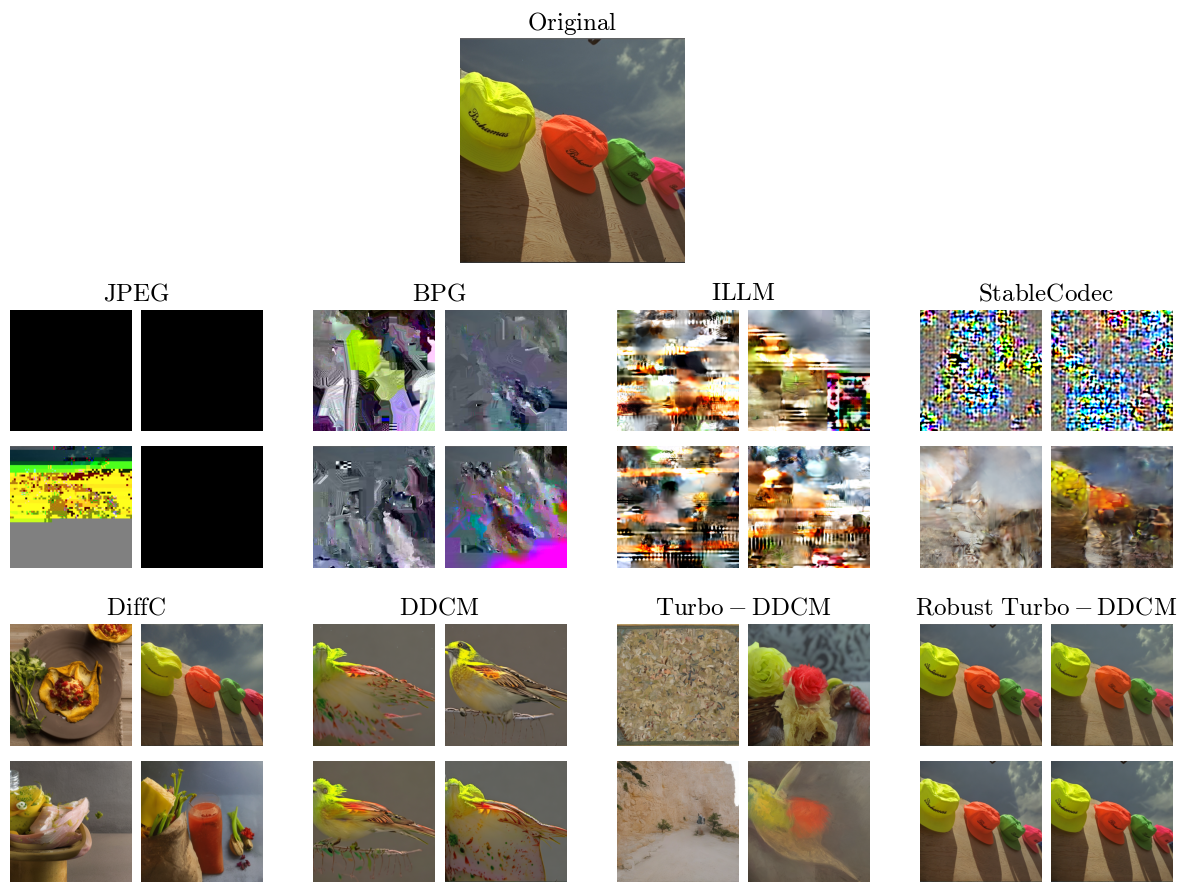

In [215]:
dataset_name = 'dataset_Kodak24'
img_index = 3
ber = '0.001'

save_name =  '__'.join([dataset_name, str(ber), str(img_index)])
methods = [['jpeg', 'bpg', 'illm', 'stable_codec'], ['diffc', 'ddcm', 'turbo_ddcm', 'robust_turbo_ddcm']]
paths = []
for idx in range(2):
    tmp_path = []
    for method in methods[idx]:
        tmp_path += [get_paths(method, dataset_name, img_index, ber, 4)]
    paths.append(tmp_path)
plot_4x(paths, methods, dataset_name, save_name, get_paths('original', dataset_name, img_index, ber, 4)[0])

In [216]:
LABELS_SHORTEN = {'jpeg': 'JPEG', 'turbo_ddcm': 'T-DDCM', 'robust_turbo_ddcm': 'Robust Turbo-DDCM', 'ddcm': 'DDCM', 'bpg': 'BPG', 'robustB10' : 'Robust T-DDCM B=10', 'diffc' : 'DiffC', 'illm' : 'ILLM', 'VAE Bound' : 'VAE Bound', 'stable_codec' : 'S.C.', 'original' : 'Original'}

BERS = {'0.0001' : '10^{-4}', '0.001' : '10^{-3}'}

def plot_row(paths, methods, bers, save_name=None):
    cols = (len(methods) - 2) // 2 + 2
    fig, axes = plt.subplots(2, cols, figsize=(13, 5))
    title_font_size = 15
    for row in range(2):
        path_idx = 0
        for col_idx in range(cols):
            ax = axes[row, col_idx]

            if (col_idx == 0) or (col_idx == (cols - 1)):
                img = np.array(Image.open(paths[row][path_idx]))
                path_idx += 1
                ax.imshow(img)
                ax.axis("off")

                if row == 0:
                    ax.set_title(tex_label(LABELS[methods[path_idx-1]]), fontsize=title_font_size)

                continue

            # Load left and right images
            img_left = np.array(Image.open(paths[row][path_idx]).convert("RGB"))
            path_idx += 1
            img_right = np.array(Image.open(paths[row][path_idx]).convert("RGB"))
            path_idx += 1

            # Concatenate side-by-side
            h, w, c = img_left.shape
            combined = np.concatenate([img_left[:, :w//2], img_right[:, w//2:]], axis=1)

            # Show in single subplot
            ax.imshow(combined)
            ax.axvline(x=w//2, color='white', linestyle='--', linewidth=1.8)
            ax.axis("off")

            if row == 0:
                ax.set_title(tex_label(LABELS_SHORTEN[methods[path_idx-2]]), loc='left', fontsize=title_font_size)
                ax.set_title(tex_label(LABELS_SHORTEN[methods[path_idx-1]]), loc='right', fontsize=title_font_size)

        axes[row][0].text(-0.08, 0.5, tex_label(BERS[bers[row]]), va="center", ha="right",
                              fontsize=18, rotation=0, transform=axes[row][0].transAxes)

    plt.tight_layout()

    if save_name is None:
        plt.show()
    else:
        output_dir = 'results/plots'
        os.makedirs(output_dir, exist_ok=True)
        output_path = os.path.join(output_dir, f'{save_name}.pdf')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')

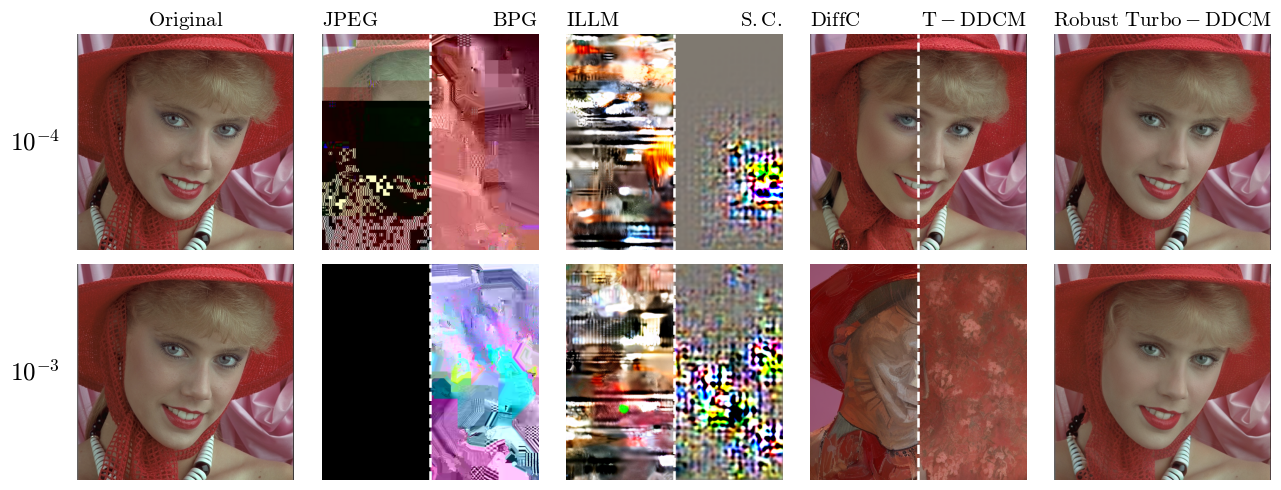

In [217]:
dataset_name = 'dataset_Kodak24'
img_index = 4
bers = ['0.0001', '0.001']

save_name =  'teaser'
methods = ['original', 'jpeg', 'bpg', 'illm', 'stable_codec', 'diffc', 'turbo_ddcm', 'robust_turbo_ddcm']
paths = []
for ber in bers:
    tmp_path = []
    for method in methods:
        tmp_path += get_paths(method, dataset_name, img_index, ber, 1)
    paths.append(tmp_path)

plot_row(paths, methods, bers, save_name)

In [70]:
print(paths[0])

['dataset_Kodak24/2.png', 'results/noisy_channel/jpeg/dataset_Kodak24/samples/ber0.0001/2_trial0.png', 'results/noisy_channel/illm/dataset_Kodak24/samples/ber0.0001/2_trial0.png', 'results/noisy_channel/stable_codec/dataset_Kodak24/samples/ber0.0001/2_trial1.png', 'results/noisy_channel/turbo_ddcm/dataset_Kodak24/samples/ber0.0001/2_trial0.png', 'results/noisy_channel/robust_turbo_ddcm/dataset_Kodak24/samples/ber0.0001/2_trial0.png']
